# Lab 18: Techniques for development of machine learning systems

In [3]:
import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

tf.keras.backend.set_floatx('float64')
tf.autograph.set_verbosity(0)

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import * 
from lib.assigment_utils import *

## I. Without a cross validation data set (REGRESSION)

### Use sklearn to split the original dataset into a training set and a test set

Aim to reserve 20-40% of the original data set for testing.

Below, 1/3 is reserved for testing and 2/3 is used for training.

In [5]:
# Generate some data
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

# Split the data using sklearn routine 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


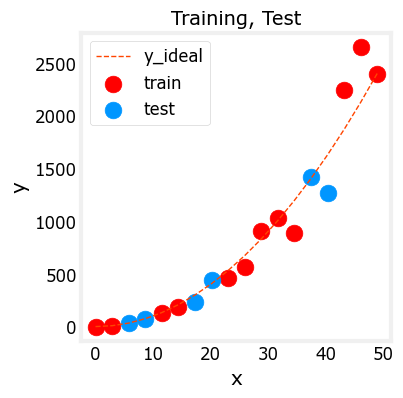

In [6]:
# Inspect the data

fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

### Calculate error with linear model

In this part we aare doing linear regression so we use squared_error to calculate loss.

In [9]:
# UNQ_C1
# GRADED CELL: eval_mse
def eval_mse(y, yhat):
    """ 
    Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:
      err: (scalar)             
    """
    m = len(y)
    err = 0.0
    for i in range(m):
    ### START CODE HERE ### 
        squared_error_i  = (yhat[i] - y[i])**2
        err += squared_error_i    
        

    mse = err / (2*m)
    err = mse
    ### END CODE HERE ### 
    
    return(err)

In [10]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 All tests passed.


### Calculate error with over-fitted high-level polynomial model

In [11]:
# create a model in sklearn, train on training data
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

# predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

# predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

In [12]:
# The computed error on the training set is substantially less than that of the test set
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 58.01, test err 171215.01


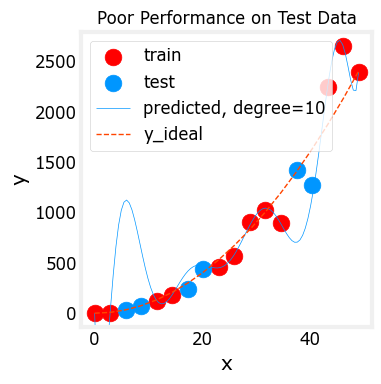

In [13]:
# plot predictions over data range 
x = np.linspace(0,int(X.max()),100)  # predict values for plot
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

## II. With a cross validation data set (REGRESSION)

* 60% training set
* 20% cross validation set
* 20% test set

### Use sklearn to split the data

In [14]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine 
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


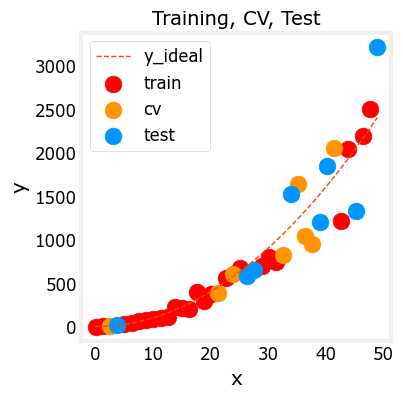

In [16]:
# Plot the multiple data set

fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, CV, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

### Generate 9 versions of polynomial models

In [17]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

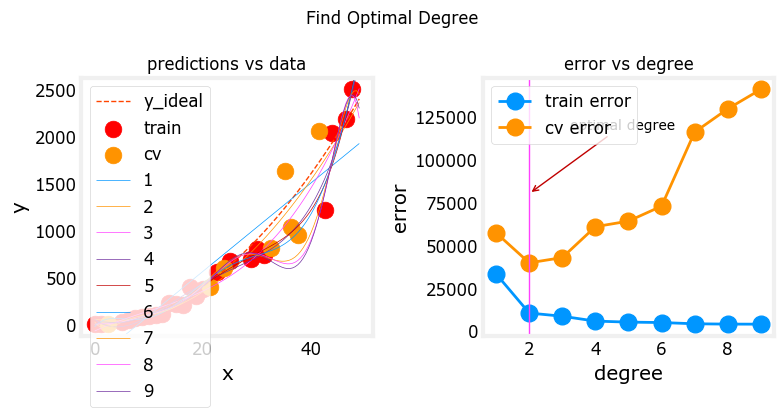

In [21]:
# plot the result
# From the plot of error/loss vs degree of polynomial (on the right), we can see that the 2nd degree polynomial is the best at this point.
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

### Fine-tune with regularization'

Start with a high-degree polynomial (10th degree) and vary the regularization parameter (lambda).

In [22]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv) 

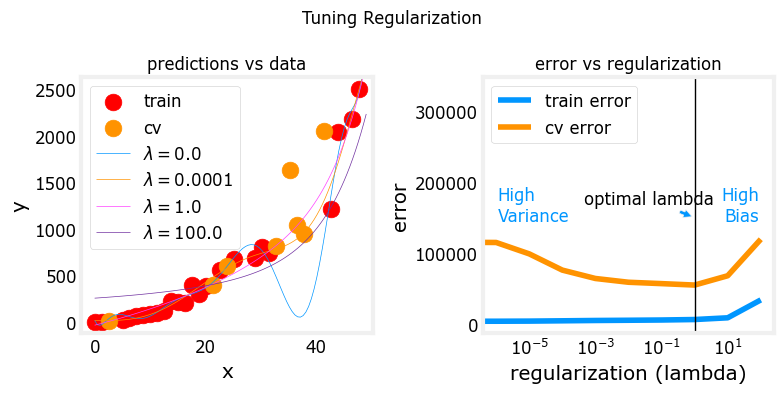

In [24]:
# plot the result
# From the plot of error/loss vs value of lambda (on the right), we can see the optimal lambda value (when loss of both the training set and cross validation set are low)
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

## Collect additional data to to lower the variance

Generally, more data improves generalization. If the model has low bias (low loss on the training set relative to benchmark) but high variance (high loss on the cross validation set relative to the training set), then adding more training data improves how the model accommodates new inputs (decreases variance). But adding more examples when the model has high bias (underfitted) does not improve performance.

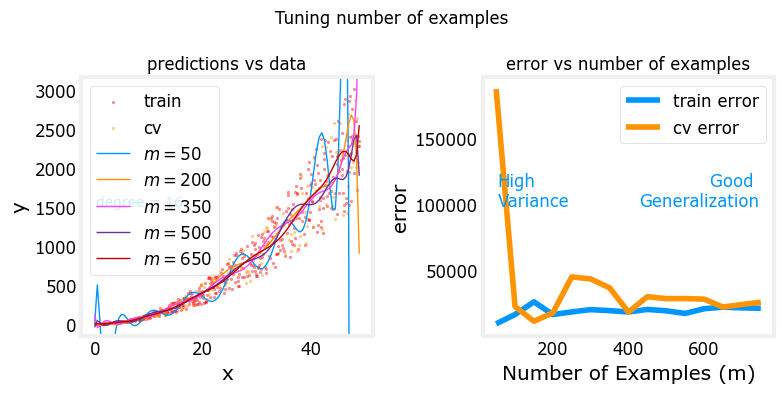

In [25]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

## III. Evaluate a neural network (CLASSIFICATION)

### Create a classification dataset

In [16]:
# Generate and split data set
X, y, centers, classes, std = gen_blobs()

# split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


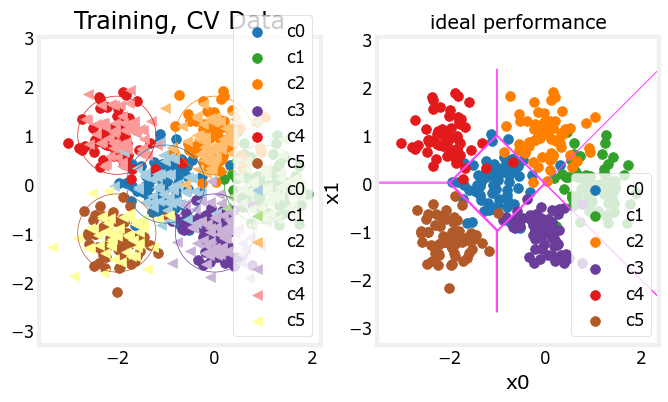

In [17]:
# plot
# On the right is an example of an 'ideal' model, or a model one might create knowing the source of the data. The lines represent 'equal distance' boundaries where the distance between center points is equal. 
# It's worth noting that this model would "misclassify" roughly 8% of the total data set.
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

### Calculate error

In [18]:
# UNQ_C2
# GRADED CELL: eval_cat_err
def eval_cat_err(y, yhat):
    """ 
    Calculate the categorization error
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:|
      cerr: (scalar)             
    """
    m = len(y) # number of prediction
    incorrect = 0 # initialize a counter for misclassified data
    for i in range(m):
    ### START CODE HERE ### 

        # add to counter if misclassified
        if yhat[i] != y[i]:
            incorrect += 1
            
    # classification error (cerr)
    cerr = incorrect / m
    
    ### END CODE HERE ### 
    
    return(cerr)



# Below is from lab 16
# # Initialize counter for misclassified data
# misclassified = 0

# # Get number of predictions
# num_predictions = len(predictions)

# # Loop over each prediction
# for i in range(num_predictions):
    
#     # Check if it matches the ground truth
#     if predictions[i] != ground_truth[i]:
        
#         # Add one to the counter if the prediction is wrong
#         misclassified += 1

# # Compute the fraction of the data that the model misclassified
# fraction_error = misclassified/num_predictions

In [19]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.


## Build complex model with tensorflow

Compose a three-layer model:
* Dense layer with 120 units, relu activation
* Dense layer with 40 units, relu activation
* Dense layer with 6 units and a linear activation (not softmax)

Compile using loss with `SparseCategoricalCrossentropy`.
Remember to use `from_logits=True` and Adam optimizer with learning rate of `0.01`.

In [20]:
# UNQ_C3
# GRADED CELL: model
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(1234)
model = Sequential(
    [
        ### START CODE HERE ### 
        Dense(120, activation='relu', name='L1'),
        Dense(40, activation='relu', name='L2'),
        Dense(6, activation='linear', name='L3'), 
        ### END CODE HERE ### 

    ], name="Complex"
)
model.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # from_logits=True minimizes roundoff error
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # adds Adam algorithm to make gradient descent faster
    ### END CODE HERE ### 
)

In [22]:
# BEGIN UNIT TEST
model.fit(
    X_train, y_train,
    epochs=500 # I changed this from 1000 to 500 to expedite processing on local machine.
)
# END UNIT TEST

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0714 
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1112 
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1033 
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1749 
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1440 
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1070 
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1766 
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0951 
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0639 
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0709 
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0865 
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0967 
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0638 
Epoch 14/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0515 
Epoch 15/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - los

In [23]:
# BEGIN UNIT TEST
model.summary()

model_test(model, classes, X_train.shape[1]) 
# END UNIT TEST

# Error raised `The layer Complex has never been called and thus has no defined input.` does not occur in course notebook.

Model: "Complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

AttributeError: The layer Complex has never been called and thus has no defined input.

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 270us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 248us/step


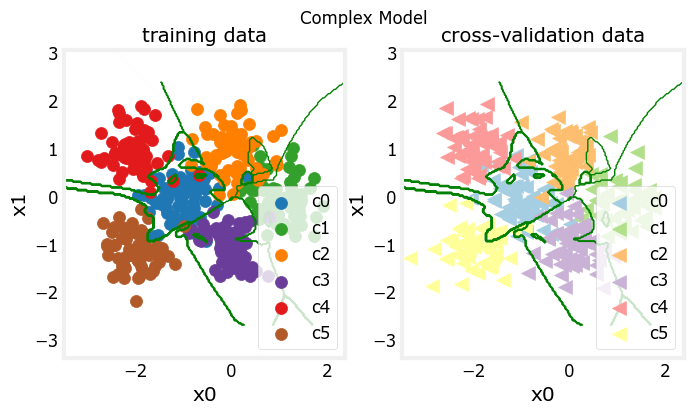

In [24]:
#make a model for plotting routines to call
# This complex model has worked very hard to capture outliers of each category (overfitted).
# As a result, it has miscategorized some of the cross-validation data. Let's calculate the classification error.

model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

In [25]:
# Calculate error
# Because the model is over-fitted, the training error is low but the cross validation error is high.
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
categorization error, training, complex model: 0.007
categorization error, cv,       complex model: 0.103


### Build simple model

Compose a two-layer model:
* Dense layer with 6 units, relu activation
* Dense layer with 6 units and a linear activation. Compile using
* Loss with `SparseCategoricalCrossentropy` with `from_logits=True`
* Adam optimizer with learning rate of `0.01`.

In [26]:
# UNQ_C4
# GRADED CELL: model_s

tf.random.set_seed(1234)
model_s = Sequential(
    [
        ### START CODE HERE ### 
        Dense(6, activation='relu', name='L1'),
        Dense(6, activation='linear', name='L2'),
        ### END CODE HERE ### 
    ], name = "Simple"
)
model_s.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # from_logits=True minimizes roundoff error
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # adds Adam algorithm to make gradient descent faster
    ### START CODE HERE ### 
)

In [27]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# BEGIN UNIT TEST
model_s.fit(
    X_train,y_train,
    epochs=500 # I changed this from 1000 to 500 to expedite processing on local machine
)
# END UNIT TEST

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6057  
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3367 
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1550 
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0167 
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8967 
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7852 
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6842 
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5962 
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5248 
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4702 
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4323 
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4035 
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3809 
Epoch 14/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3622 
Epoch 15/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [28]:
# BEGIN UNIT TEST
model_s.summary()

model_s_test(model_s, classes, X_train.shape[1])
# END UNIT TEST

# Error raised `The layer Simple has never been called and thus has no defined input.` does not occur in course notebook.

Model: "Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182 (1.42 KB)

 Trainable params: 60 (480.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (976.00 B)

AttributeError: The layer Simple has never been called and thus has no defined input.

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 228us/step


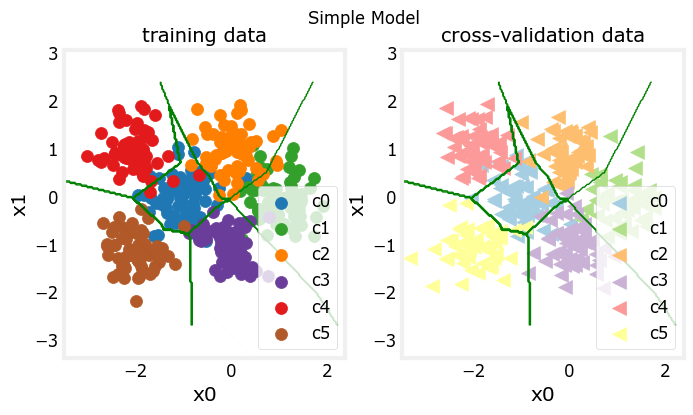

In [29]:
#make a model for plotting routines to call
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

In [30]:
# Calculate error
# Because the model is not over-fitted, the training loss is not as low (as the complex model) but the cross validation loss is much better.
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
categorization error, training, simple model, 0.072, complex model: 0.007
categorization error, cv,       simple model, 0.072, complex model: 0.103


### Reconstruct the complex model with regularization

Compose a three-layer model:
* Dense layer with 120 units, relu activation, `kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* Dense layer with 40 units, relu activation, `kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* Dense layer with 6 units and a linear activation.
* Compile using loss with `SparseCategoricalCrossentropy` with `from_logits=True`
* Adam optimizer with learning rate of `0.01`.

In [31]:
# UNQ_C5
# GRADED CELL: model_r

tf.random.set_seed(1234)
model_r = Sequential(
    [
        ### START CODE HERE ### 
        Dense(120, activation='relu', name='L1', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(40, activation='relu', name='L2', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(6, activation='linear', name='L3'), 
        ### START CODE HERE ### 
    ], name= None
)
model_r.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    ### START CODE HERE ### 
)

In [32]:
# BEGIN UNIT TEST
model_r.fit(
    X_train, y_train,
    epochs=500 # I changed this from 1000 to 500 to expedite processing on local machine
)
# END UNIT TEST

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8222  
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6956 
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3115 
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0915 
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9890 
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9417 
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8860 
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8403 
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8055 
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7836 
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7655 
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7496 
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7345 
Epoch 14/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7215 
Epoch 15/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [33]:
# BEGIN UNIT TEST
model_r.summary()

model_r_test(model_r, classes, X_train.shape[1]) 
# END UNIT TEST

# Error `The layer sequential has never been called and thus has no defined input.` does not occur in course lab.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

ddd


AttributeError: The layer sequential_1 has never been called and thus has no defined input.

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step


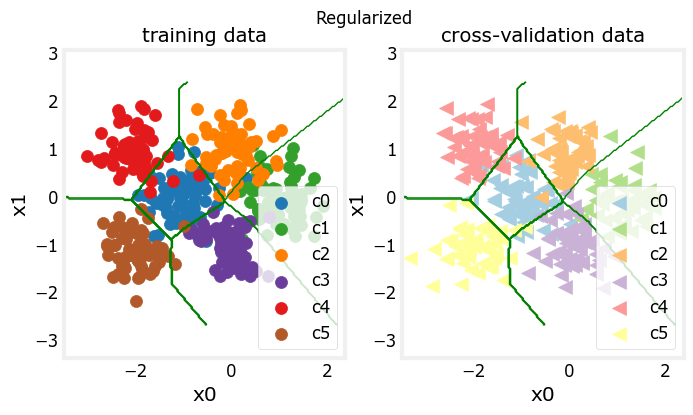

In [12]:
# plot results of regularized complex model
# The regularized, complex model is close to an ideal delineation
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)
 
plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

In [34]:
# Calculate error
# The loss on the training set is less for the simple (un-regularized) model.
# But the loss on the cross validation set is much lower for the regularized complex model.

training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
categorization error, training, regularized: 0.080, simple model, 0.072, complex model: 0.007
categorization error, cv,       regularized: 0.069, simple model, 0.072, complex model: 0.103


### Optimize the regularization parameter (lambda)

In [ ]:
# Do not run the below code locally. It is too resource-intensive.

tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)

for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000
    )
    print(f"Finished lambda = {lambda_}")

In [35]:
# Plot the losses for each value of lambda
# As regularization (lambda) is increased, the performance of the model on the training and cross-validation data sets lower and converge. 
# In this scenario, lambda > 0.01 is a reasonable choice.
plot_iterate(lambdas, models, X_train, y_train, X_cv, y_cv)

NameError: name 'lambdas' is not defined

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


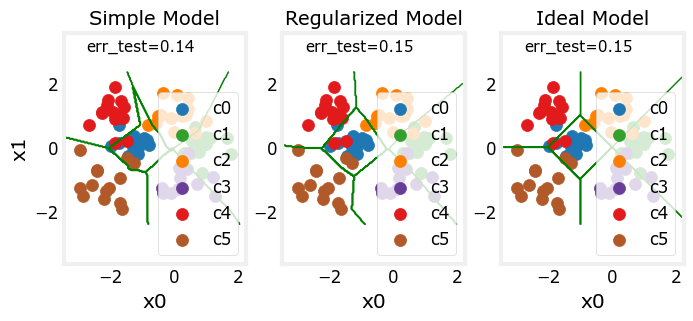

In [36]:
plt_compare(X_test,y_test, classes, model_predict_s, model_predict_r, centers)